In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
from pathlib import Path

# Paths
RAW_DIR = Path(r"C:\Users\saxen\OneDrive\Desktop\NISAR_Project\data\raw")
PROCESSED_DIR = Path(r"C:\Users\saxen\OneDrive\Desktop\NISAR_Project\data\processed")
OUTPUT_DIR = Path(r"C:\Users\saxen\OneDrive\Desktop\NISAR_Project\outputs")

# Get your downloaded file
files = list(RAW_DIR.glob("*.nc"))
print(f"Found {len(files)} file(s):")
for f in files:
    print(f"  - {f.name}")

Found 3 file(s):
  - S1-GUNW-A-R-143-tops-20220810_20210827-114943-00092E_00027N-PP-a9bd-v2_0_5.nc
  - S1-GUNW-A-R-143-tops-20220810_20220729-114943-00092E_00027N-PP-a4e2-v2_0_5.nc
  - S1-GUNW-A-R-143-tops-20221009_20220927-114945-00092E_00027N-PP-12dc-v2_0_5.nc


In [2]:
def explore_hdf5(filepath):
    with h5py.File(filepath, 'r') as f:
        print("📦 FILE STRUCTURE")
        print("=" * 60)
        def printer(name, obj):
            indent = "  " * name.count('/')
            tag = "📊" if isinstance(obj, h5py.Dataset) else "📁"
            shape = f" | shape: {obj.shape}" if isinstance(obj, h5py.Dataset) else ""
            print(f"{indent}{tag} {name.split('/')[-1]}{shape}")
        f.visititems(printer)

explore_hdf5(files[0])

📦 FILE STRUCTURE
📊 crs_polygon | shape: ()
📊 matchup | shape: (0,)
📊 productBoundingBox | shape: (1, 449)
📁 science
  📁 grids
    📁 corrections
      📁 derived
        📁 ionosphere
          📊 ionosphere | shape: (1,)
      📁 external
        📁 tides
          📊 solidEarthTide | shape: (1,)
        📁 troposphere
          📊 troposphereHydrostatic | shape: (1,)
          📊 troposphereWet | shape: (1,)
    📁 data
      📊 amplitude | shape: (2273, 3576)
      📊 coherence | shape: (2273, 3576)
      📊 connectedComponents | shape: (2273, 3576)
      📊 crs | shape: ()
      📊 latitude | shape: (2273,)
      📊 longitude | shape: (3576,)
      📊 unwrappedPhase | shape: (2273, 3576)
    📁 imagingGeometry
      📊 azimuthAngle | shape: (4, 26, 35)
      📊 crsMeta | shape: ()
      📊 heightsMeta | shape: (4,)
      📊 incidenceAngle | shape: (4, 26, 35)
      📊 latitudeMeta | shape: (26,)
      📊 longitudeMeta | shape: (35,)
      📊 lookAngle | shape: (4, 26, 35)
      📊 parallelBaseline | shape: (

In [3]:
def extract_layers(filepath):
    with h5py.File(filepath, 'r') as f:
        print("Searching for unwrappedPhase...")
        
        found_phase = None
        found_coherence = None
        
        def find_datasets(name, obj):
            nonlocal found_phase, found_coherence
            if isinstance(obj, h5py.Dataset):
                if 'unwrappedPhase' in name and found_phase is None:
                    found_phase = name
                if 'coherence' in name and found_coherence is None:
                    found_coherence = name
        
        f.visititems(find_datasets)
        
        print(f"✅ Found phase at:     {found_phase}")
        print(f"✅ Found coherence at: {found_coherence}")
        
        unwrapped = f[found_phase][:]
        coherence = f[found_coherence][:]
        
    print(f"Phase shape: {unwrapped.shape}")
    print(f"Coherence shape: {coherence.shape}")
    return unwrapped, coherence, None, None

unwrapped, coherence, lat, lon = extract_layers(files[0])

Searching for unwrappedPhase...
✅ Found phase at:     science/grids/data/unwrappedPhase
✅ Found coherence at: science/grids/data/coherence
Phase shape: (2273, 3576)
Coherence shape: (2273, 3576)


In [4]:
# Sentinel-1 C-band wavelength = 5.5 cm
# NISAR L-band wavelength = 23.8 cm (use this when switching to real NISAR data)
WAVELENGTH = 0.055465  # meters, Sentinel-1

def phase_to_displacement_cm(phase, wavelength=WAVELENGTH):
    """
    Converts unwrapped InSAR phase to Line-of-Sight displacement in cm.
    Positive = ground moving toward satellite (uplift)
    Negative = ground moving away from satellite (subsidence/down)
    """
    return (phase / (4 * np.pi)) * wavelength * 100

displacement = phase_to_displacement_cm(unwrapped)

print(f"Max uplift:     {np.nanmax(displacement):.1f} cm")
print(f"Max subsidence: {np.nanmin(displacement):.1f} cm")

Max uplift:     7.1 cm
Max subsidence: -25.3 cm


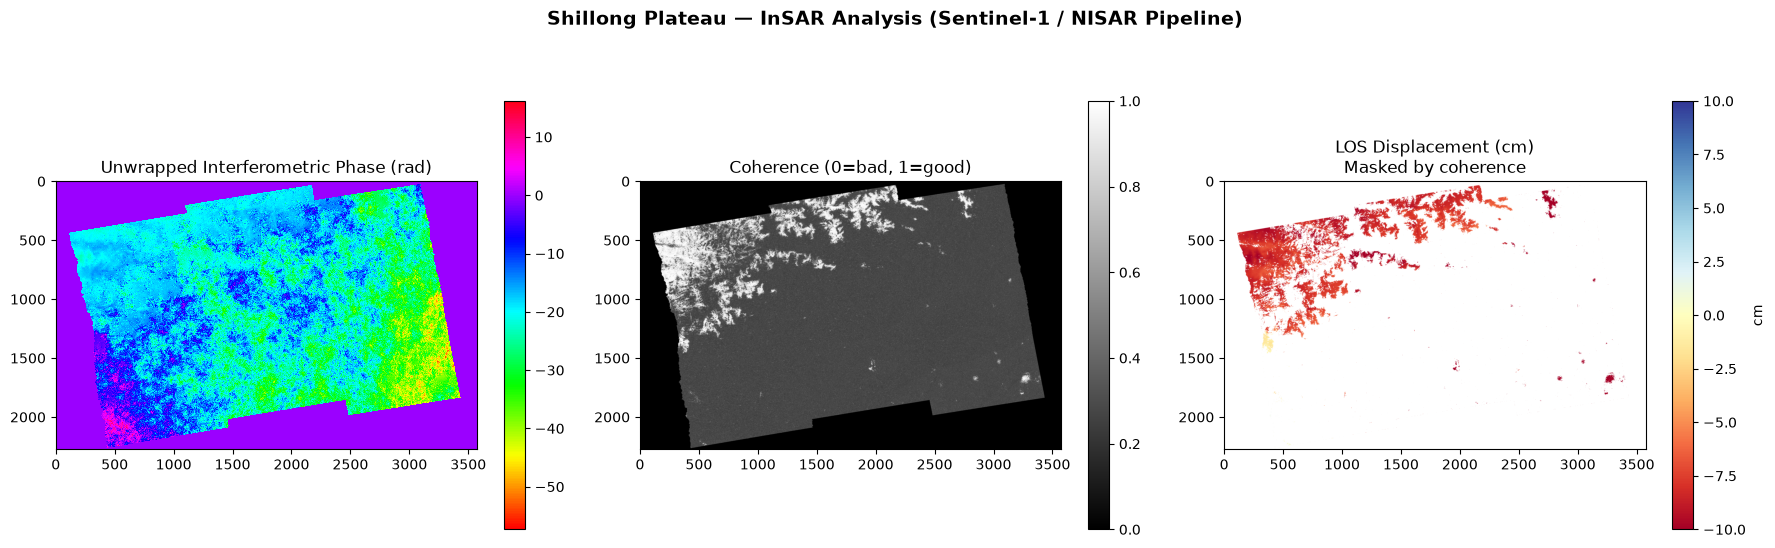

✅ Saved to C:\Users\saxen\OneDrive\Desktop\NISAR_Project\outputs\shillong_displacement_map.png


In [5]:
COHERENCE_THRESHOLD = 0.5

# Mask unreliable pixels
mask = coherence < COHERENCE_THRESHOLD
displacement_masked = np.where(mask, np.nan, displacement)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Shillong Plateau — InSAR Analysis (Sentinel-1 / NISAR Pipeline)',
             fontsize=14, fontweight='bold')

# Unwrapped phase
im0 = axes[0].imshow(unwrapped, cmap='hsv', interpolation='nearest')
axes[0].set_title('Unwrapped Interferometric Phase (rad)')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Coherence
im1 = axes[1].imshow(coherence, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Coherence (0=bad, 1=good)')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Displacement
im2 = axes[2].imshow(displacement_masked, cmap='RdYlBu', vmin=-10, vmax=10)
axes[2].set_title('LOS Displacement (cm)\nMasked by coherence')
plt.colorbar(im2, ax=axes[2], label='cm', shrink=0.8)

plt.tight_layout()
out_path = OUTPUT_DIR / 'shillong_displacement_map.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved to {out_path}")

In [6]:
valid_pixels = displacement_masked[~np.isnan(displacement_masked)]

print("=" * 45)
print("  SHILLONG PLATEAU — DEFORMATION SUMMARY")
print("=" * 45)
print(f"  Total valid pixels analyzed : {len(valid_pixels):,}")
print(f"  Mean LOS displacement       : {np.mean(valid_pixels):.2f} cm")
print(f"  Max uplift detected         : {np.max(valid_pixels):.2f} cm")
print(f"  Max subsidence detected     : {np.min(valid_pixels):.2f} cm")
print(f"  Std deviation               : {np.std(valid_pixels):.2f} cm")
print("=" * 45)

# Save stats
import json
stats = {
    "region": "Shillong Plateau, Northeast India",
    "fault": "Oldham Fault",
    "valid_pixels": int(len(valid_pixels)),
    "mean_displacement_cm": float(np.mean(valid_pixels)),
    "max_uplift_cm": float(np.max(valid_pixels)),
    "max_subsidence_cm": float(np.min(valid_pixels)),
    "std_cm": float(np.std(valid_pixels))
}
with open(PROCESSED_DIR / 'deformation_stats.json', 'w') as f:
    json.dump(stats, f, indent=2)
print("✅ Stats saved to processed/deformation_stats.json")

  SHILLONG PLATEAU — DEFORMATION SUMMARY
  Total valid pixels analyzed : 604,392
  Mean LOS displacement       : -8.16 cm
  Max uplift detected         : 4.05 cm
  Max subsidence detected     : -21.74 cm
  Std deviation               : 1.59 cm
✅ Stats saved to processed/deformation_stats.json


In [7]:
np.save(PROCESSED_DIR / 'displacement_masked.npy', displacement_masked)
np.save(PROCESSED_DIR / 'coherence.npy', coherence)
print("✅ All processed arrays saved!")
print("\nYour outputs folder now contains:")
for f in OUTPUT_DIR.iterdir():
    print(f"  📄 {f.name}")

✅ All processed arrays saved!

Your outputs folder now contains:
  📄 shillong_displacement_map.png
